<a href="https://colab.research.google.com/github/robertogff/testrepo/blob/master/Unidad5_RobertoSernaBlasco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importar librerias y datos

In [2]:
# Importar librerias
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from keras.layers import LeakyReLU

In [5]:
# Importo el archivo que contiene la codificación ortogonal obtenida en la primera PEC.
orthogonal_encod = np.genfromtxt ("./octameros.csv",
                                  delimiter=',', skip_header=1)

# Importo el archivo de datos acerca de los octámeros, incluyendo si tienen cleavaje site o no.
octamer_data = np.genfromtxt ("./datos.csv",
                               delimiter=',', skip_header=1)

octamer_data_pd = pd.read_csv ("./datos.csv",
                                  sep=',', header=0, dtype={'V1':'string', 'V2':'category'})

# Visualización de los datos

Leer los datos desde los ficheros datos.csv y octameros.csv. El fichero datos.csv contiene las
secuencias de octameros y la clase. El fichero octameros.csv contiene las secuencias de octameros
en la codificación one-hot en su representación vectorial (vector de 160). Dado que se espera que los datos que espera la red neuronal deben ser de tipo matriz, construiremos matrices de 8x20 (8 elementos del octamero por 20 posibles aminoacidos)

In [6]:
print('Los octameros se han importdo con el siguiente formato', orthogonal_encod[0,].shape)
print('por ejemplo')
print(orthogonal_encod[0,])

# Generamos matrices a partir de estos vectores
## Ejemplo con el mismo vector para convertirlo en matriz y crear el objeto octamers (que será un 3D numpy array)
octamers = [orthogonal_encod[0,].reshape([8,20])]

# Para hacerlo con el resto de vectores vamos a hacer primero una lista de matrices
octamers_list = []

for i in range(len(orthogonal_encod)):
    octamer = orthogonal_encod[i].reshape(8, 20)
    octamers_list.append(octamer)

# Convertir la lista a array numpy 3D
octamers = np.array(octamers_list)

# Formato de los octameros tras la transformacion
print('Este es el formato actual de los octameros')
print(octamers[5,])

print('Hemos generado %d matrices', len(octamers))
print('El formato de nuestros datos en forma de matrices:', octamers.shape)


Los octameros se han importdo con el siguiente formato (160,)
por ejemplo
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Este es el formato actual de los octameros
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 

In [7]:
# Información acerca de los octameros
print('Octámeros')
print(octamer_data_pd.info())
print(octamer_data_pd.describe())

Octámeros
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4149 entries, 0 to 4148
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   V1      4149 non-null   string  
 1   V2      4149 non-null   category
dtypes: category(1), string(1)
memory usage: 36.6 KB
None
              V1    V2
count       4149  4149
unique      4148     2
top     VEEGIVLG     0
freq           2  3575


In [37]:
display(octamer_data_pd)

,V1,V2
0,AAAAAPAK,0
1,AAAAPAKV,0
2,AAAELGAR,0
3,AAAPAKVE,0
4,AAAPVAAA,0
...,...,...
4144,YLDAGLAR,0
4145,YQAKLAEQ,0
4146,YQALDADF,0
4147,YQELLVNQ,1


<Axes: ylabel='count'>

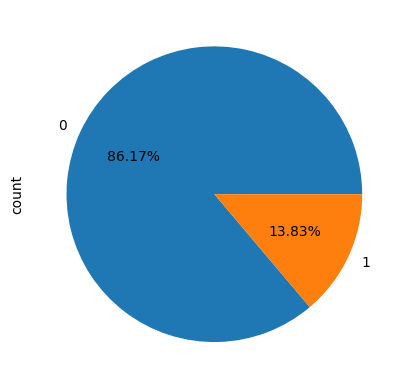

In [8]:
# Visualizacion
octamer_data_pd['V2'].value_counts().plot.pie(autopct='%.2f%%')

Preparación de los datos. Utilizando la semilla aleatoria, separar los datos en dos partes, una parte para training (67%) y una parte para test (33%).

In [9]:
from sklearn.model_selection import train_test_split

# Especificamos las etiquetas de cada octamero, sera 0 si no tiene cleavaje site y 1 si lo tiene
labels = octamer_data[:,1]
labels = labels.astype('int64') # Asegura que las etiquetas son enteros (0 o 1) para clasificación
print(labels[0:15])

# Dividimos los datos en un subconjunto para entrenamiento (67%) y un subconjunto de prueba (33%),
# mantenemos por separado los octameros de las etiquetas.
octamer_train, octamer_test, labels_train, labels_test = train_test_split(octamers, labels, test_size = 0.33,
                                                                          random_state= 2) # random_state asegura
                                                                                           # la reproducibilidad

[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


In [10]:
print ('Nº de octámeros de entrenamiento:', octamer_train.shape)
print ('Etiquetas para los datos de entrenamiento:', labels_train.shape)
print (' ')
print ('Nº de octámeros de prueba:', octamer_test.shape)
print ('Etiquetas para los datos de entrenamiento:', labels_test.shape)

Nº de octámeros de entrenamiento: (2779, 8, 20)
Etiquetas para los datos de entrenamiento: (2779,)
 
Nº de octámeros de prueba: (1370, 8, 20)
Etiquetas para los datos de entrenamiento: (1370,)


Observamos que el subgrupos de datos para el entrenamiento tiene una forma 2779x8x20, esto significa que hay 2779 muestras de dimensiones 8x20. Mientras que en el sbgrupo de prueba, hay 1370 instancias con las mismas dimensiones, 8x20.

Procesado adicional de los datos:

Se debe convertir nuestras 'imagenes' (matrices) de 8x20 en matrices de 8x20x1, ya que es el formato de input de nuestra red neuronal convolucional. La última dimension que añadimos corresponde a la profundidad o *depth* y hace referencia al número de cualidades entre las ucales debe de distinguir la red (en nuestro caso es 1 porque solamente tiene entre cleavege/ no cleaveage)

In [11]:
octamer_train = octamer_train.reshape(-1, 8, 20, 1) # el primer argumento -1 es para mantener el numero de arrays
octamer_test = octamer_test.reshape(-1, 8, 20, 1)
print('Las dimensiones de los arrays de entrenamiento y prueva con los que vamos a alimentar la red son respectivamente:')
octamer_train.shape, octamer_test.shape

Las dimensiones de los arrays de entrenamiento y prueva con los que vamos a alimentar la red son respectivamente:


((2779, 8, 20, 1), (1370, 8, 20, 1))

In [12]:
# Nos aseguramos del formato de los datos de las matrices
octamer_train = octamer_train.astype('float32')
octamer_test = octamer_test.astype('float32')

Por último, las etiquetas que informan acerca de la clase (cleavage/no cleavage) deben estar en formato "one-hot encoding vector". Este es el mismo formato que utilizamos para codificar los octámeros, es decir, se transforman los datos categóricos en datos numéricos creando vectores consistentes en ceros salvo para la clase que representa, que será uno. Como en nuestro estudio solamente tenemos dos clases quedará de la siguiente manera: si la clase es 0 (no cleavage) se codificará como [1,0] y, si la clase es 1 (cleavage), se codificará como [0,1].

In [13]:
# Numero de clases de la variable (2)
num_classes = 2

# Cambiamos las labels de categorical a 'one-hot encoding'
labels_train_one_hot = to_categorical(labels_train)
labels_test_one_hot = to_categorical(labels_test)

# Vemos los cambios
print('Etiqueta (label) original:', labels_train[10])
print('Tras la conversión "one-hot":', labels_train_one_hot[10])
print ('\n')
print('Etiqueta (label) original:', labels_train[5])
print('Tras la conversión "one-hot":', labels_train_one_hot[5])

Etiqueta (label) original: 1
Tras la conversión "one-hot": [0. 1.]


Etiqueta (label) original: 0
Tras la conversión "one-hot": [1. 0.]


# Entrenamiento de la CNN

## Construcción del modelo

Vamos a generar una red con 2 capas convolucionales:


*   Primera: 32 filtros/ventanas de 3x3
*   Segunda: 64 filtros/ventanas de 3x3

Utilizaremos un keras Conv2D() ya que estamos tratando con matrices de dos dimensiones. La función de activación que utilizaremos para estas capas es *leaky ReLU*. Esta función es similara a ReLU salvo que añade una pequeña pendiente para los valores negativos en lugar de ser pendiente 0. Este tipo de función de activación pretende resolver el problmea de las *dying ReLU*.

Cada capa convulocional se seguirá por una capa de agrupación (*pooling*) de 2x2, con la función MaxPooling2D(). Esta capa crea una versión condensada de la información contenida en las ventanas generadas de la capa convolucional previa. Esta técnica permite reducir las dimensiones y ayuda a reducir el *overfitting*.

Para finalizar añadiremos una capa densa y, dado que nuestro output es binario, la función de activación de salilda será sigmoidea.

In [14]:
model = Sequential() # Inicializa un modelo de red neuronal secuencial
model.add(Conv2D(32, kernel_size=(3,3), activation='linear', input_shape = (8,20,1), padding='same')) # Añade la primera capa convolucional con 32 filtros y un kernel de 3x3
model.add(LeakyReLU(alpha = 0.1)) # Aplica la función de activación Leaky ReLU
model.add(MaxPooling2D((2,2), padding = 'same')) # Añade una capa de Max Pooling para reducir las dimensiones
model.add(Conv2D(64, kernel_size=(3,3), activation='linear', padding='same')) # Añade la segunda capa convolucional con 64 filtros
model.add(MaxPooling2D(pool_size=(2,2), padding='same')) # Añade otra capa de Max Pooling
model.add(Flatten()) # Convierte la salida de las capas convolucionales en un vector 1D
model.add(Dense(128, activation='linear')) # Añade una capa densa (fully connected) con 128 neuronas
model.add(LeakyReLU(alpha=0.1)) # Aplica la función de activación Leaky ReLU a la capa densa
model.add(Dense(num_classes, activation='sigmoid')) # Añade la capa de salida con activación sigmoide para clasificación binaria

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


## Compilación del modelo

Utilizaremos el optimizador Adam (Adaptative Moment Estimation) que nos permite adaptar la tasa de aprendizaje y evitar el problema de los mínimos locales. Además, si debemos especificar el 'loss function' o la función de pérdida, que tratándose de un clasificador binario será binary cross-entropy. Si especificamos *accuracy* para la variable 'metrics' podremos ver el progreso de la exactitud del modelo a medida que avanza el entrenamiento.

In [15]:
model.compile(loss = keras.losses.binary_focal_crossentropy,
              optimizer = keras.optimizers.Adam(),
              metrics = ['accuracy'])

# Visualizar el modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 20, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 8, 20, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 10, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 10, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,122 (395.01 KB)

 Trainable params: 101,122 (395.01 KB)

 Non-trainable params: 0 (0.00 B)

## Modelado de los datos



*   Batch size: Generalmente no se introducen todos los datos disponibles juntos en una iteración a través de la red neuronal, si no que se seleccionan muestras aleatorias de estos datos. El *batch size* define el número de muestras que se deben seleccionar de forma aleatoria para cada iteracción. Esto permite aumentar la aleatoriedad. He seleccionado un batch size de 60.

*   Epoch: un epoch o época es in ciclo del algoritmo en el que la red be todas las muestras disponibles una vez. Dado que estamos aprtiendo los datos en batches y el cálculo del gradiente decreciente es un proceso iterativo, una sola época no es suficiente. Hay que determinar el número de épocas que deseamos que realice nuestra red teniendo en cuenta que a medida que aumenta el número, aumenta el riesfo de overfitting. Mi red neuronal realizará 16 ciclos.

*   Val_split: Un porcentaje de los datos del train no se usan en el proceso de entrenamiento. Se denominan datos de validación. Se usa para valorar el rendimiento durante el proceso de entrenamiento.



In [16]:
batch_size = 60
epochs = 16
val_splits = 0.2

## Entrenamiento del modelo

In [18]:
x = model.fit(octamer_train, labels_train_one_hot,
              batch_size = batch_size, epochs = epochs,
              verbose = 1,
              validation_split = val_splits)

Epoch 1/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8724 - loss: 0.1144 - val_accuracy: 0.8705 - val_loss: 0.0905
Epoch 2/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8649 - loss: 0.0901 - val_accuracy: 0.8759 - val_loss: 0.0801
Epoch 3/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8816 - loss: 0.0810 - val_accuracy: 0.8921 - val_loss: 0.0719
Epoch 4/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9058 - loss: 0.0648 - val_accuracy: 0.8903 - val_loss: 0.0684
Epoch 5/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9149 - loss: 0.0544 - val_accuracy: 0.9101 - val_loss: 0.0613
Epoch 6/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9275 - loss: 0.0442 - val_accuracy: 0.8993 - val_loss: 0.0694
Epoch 7/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9549 - loss: 0.0345 - val_accuracy: 0.9101 - val_loss: 0.0681
Epoch 8/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9629 - loss: 0.0261 - val_accuracy: 0.9083 - v

Podemos observar que el modelo funciona bastante bien tras 16 épocas ya que tiene una precisión del 99% paara los datos de entrenamiento. También ver que se está produciendo *overfitting* porque la precisión para los datos de validación es menor.

Observamos este fenómeno también en los siguientes gráficos. En el eje x se marcan las épocas y en el eje y la exactitud/accuracy (primer gráfico) o la pérdida (segundo gráfico). La exactitud /acccuracy para los datos del testing aumenta junto con la de los datos de entrenamiento hasta la cuarta o quinta época, a partir de la cual la exactitud para los datos de validación se estanca. El mismo fenómeno se observa con los datos de 'loss'. Esto es un signo de overfitting ya que el modelo está memorizando los datos.

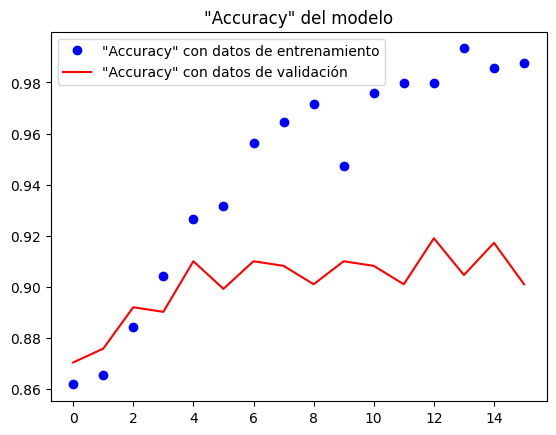

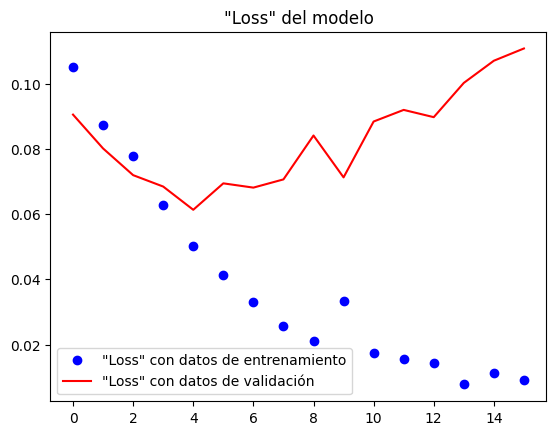

In [19]:
accuracy = x.history['accuracy']
val_accuracy = x.history['val_accuracy']
loss = x.history['loss']
val_loss = x.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label = '"Accuracy" con datos de entrenamiento')
plt.plot(epochs, val_accuracy, 'r', label = '"Accuracy" con datos de validación')
plt.title('"Accuracy" del modelo')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label = '"Loss" con datos de entrenamiento')
plt.plot(epochs, val_loss, 'r', label = '"Loss" con datos de validación')
plt.title('"Loss" del modelo')
plt.legend()
plt.show()

# Evaluación del modelo

Primero debemos transformar los datos que hemos obtenido como output para que puedan ser analizados.

In [21]:
# Obtenemos los valores predichos en forma de valores continuos entre 0 y 1 por lo que tendremos que
# redondear a 0 y 1, para obtener los vectores que codifican los outputs [1, 0]//[0, 1]
test_predicted_values = np.round(model.predict(octamer_test))

# Utilizaremos no.argmax() para seleccionar el valor más alto de cada línea, así volvemos
# a transformar los datos en 0 y 1 ([1,0]=0 // [0,1]=1).
test_predicted_labels = np.argmax(test_predicted_values, axis = 1)
test_predicted_labels.shape, labels_test.shape

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


((1370,), (1370,))

Evaluamos el rendimiento utilizando los siguientes parámetros:

In [22]:
# importamos las siguientes librerias para este fin
from sklearn.metrics import confusion_matrix, precision_score, cohen_kappa_score, classification_report, roc_auc_score, roc_curve

In [ ]:
## Matriz de confusión

Muestra los valores reales frente a los valores predichos. He considerado la clase positiva como los octámeros que si que tienen cleaveage site, es decir, “1”.

La tabla está distribuída de la siguiente manera:

*   columnas: la predicción realizada por la red, 0 en la primera columna y 1 en la segunda

*   filas: la clasificación real, 0 en la primera fila y en la 1 segunda

En la diagonal vemos los octámeros que se han clasificado correctamente.

In [23]:
# Confusion matrix
print('Matriz de confusión:')
conf_matrix = confusion_matrix(labels_test, test_predicted_labels)
print(conf_matrix)
print(' ')

print('Sensibilidad:', conf_matrix[1,1]/(conf_matrix[1,1]+conf_matrix[1,0]))
print('Especificidad:', conf_matrix[0,0]/(conf_matrix[0,0]+conf_matrix[0,1]))
print('Valor predictivo positivo (precisión):', conf_matrix[1,1]/(conf_matrix[1,1]+conf_matrix[0,1]))
print('Valor predictivo negativo:', conf_matrix[0,0]/(conf_matrix[0,0]+conf_matrix[1,0]))
print('Accuracy:', (conf_matrix[0,0] + conf_matrix[1,1])/(conf_matrix[0,0] + conf_matrix[1,1]+
                                                          conf_matrix[1,0] + conf_matrix[0,1]))

Matriz de confusión:
[[1118   56]
 [  72  124]]
 
Sensibilidad: 0.6326530612244898
Especificidad: 0.9522998296422487
Valor predictivo positivo (precisión): 0.6888888888888889
Valor predictivo negativo: 0.9394957983193277
Accuracy: 0.9065693430656935


## Precisión
Es la proporción de los positivos que realmente son positivos (también VPP).

In [24]:
precision_score(labels_test, test_predicted_labels)

0.6888888888888889

## Kappa o Kappa Cohen

Ajusta el "accuracy" teniendo en cuenta la probabilidad de dar con una predicción acertada al azar. Es importante para datos desequilibrados como el nuestro que tiene muchas más muestras sin cleavage site. A partir de 0.6 se considera un buen resultado.

In [25]:
cohen_kappa_score(labels_test, test_predicted_labels)

np.float64(0.605542558934677)

## ROC Curve / AUC

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
AUC:  0.93


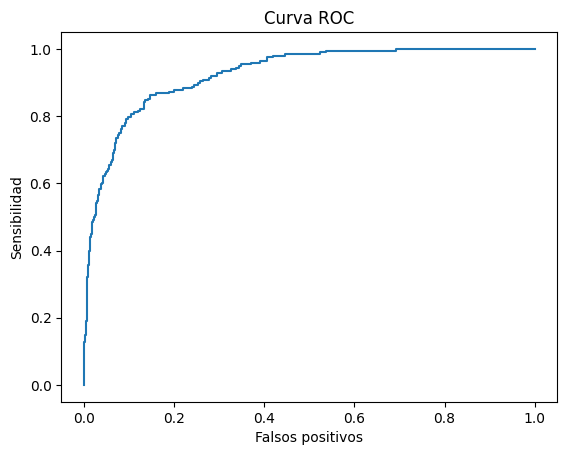

In [26]:
prob=model.predict(octamer_test)
prob_yes=prob[:,1:]
AUC=roc_auc_score(labels_test,prob_yes)
print('AUC: ',round(AUC,2))
fper,tper,tresholds=roc_curve(labels_test,prob_yes)
fig,base=plt.subplots()
base.set_title('Curva ROC')
base.set_xlabel('Falsos positivos')
base.set_ylabel('Sensibilidad')
base.plot(fper,tper)

## Classification report
Muestra la precisión tendiendo en cuenta las clases. Vemos que nuestra red clasifica mucho mejor la clase 0 (sin cleavage) que la 1. No es de extrañar ya que, como hemos comentado, la primera es mucho más frecuente en nuestra base de datos.

In [27]:
target_names = ["Class {}".format(i) for i in range(num_classes)]
print(classification_report(labels_test, test_predicted_labels, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.94      0.95      0.95      1174
     Class 1       0.69      0.63      0.66       196

    accuracy                           0.91      1370
   macro avg       0.81      0.79      0.80      1370
weighted avg       0.90      0.91      0.90      1370



# Corrección del overfitting

Podemos intentar mejorar el modelo abordando el problema del overfitting de la siguiente manera: incluímos en la red un parámetro adicional denominado dropout que permite desactivar de forma aleatora una fracción de las neuronas durante el proceso de entrenamiento. Lo que se consigue con esto es que ninguna neurona memorice parte de la entrada; que es precisamente lo que sucede cuando se produce el overfitting. Vamos a probarlo con nuestro modelo añadiendo a las capas el siguiente comando model.add(Dropout(--)). Desactivaremos el 25% de las neuronas en la primera capa y el 40% en las sucesivas.



In [28]:
batch_size = 60
epochs = 16
val_split = 0.2

In [29]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),activation='linear',input_shape=(8,20,1),padding='same'))
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D((2, 2),padding='same'))
model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3), activation='linear',padding='same'))
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D(pool_size=(2, 2),padding='same'))
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(128, activation='linear'))
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [30]:
model.compile(loss=keras.losses.binary_crossentropy,
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])

In [31]:
x_dropout = model.fit(octamer_train, labels_train_one_hot,
            batch_size=batch_size, epochs=epochs,
            verbose=1,
            validation_split= val_split)

Epoch 1/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8508 - loss: 0.4745 - val_accuracy: 0.8705 - val_loss: 0.3695
Epoch 2/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8619 - loss: 0.3948 - val_accuracy: 0.8705 - val_loss: 0.3577
Epoch 3/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8622 - loss: 0.3799 - val_accuracy: 0.8705 - val_loss: 0.3446
Epoch 4/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8672 - loss: 0.3404 - val_accuracy: 0.8705 - val_loss: 0.3110
Epoch 5/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8757 - loss: 0.3263 - val_accuracy: 0.8795 - val_loss: 0.2948
Epoch 6/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8850 - loss: 0.2986 - val_accuracy: 0.8759 - val_loss: 0.2770
Epoch 7/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8780 - loss: 0.2896 - val_accuracy: 0.8813 - val_loss: 0.2735
Epoch 8/16
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8857 - loss: 0.2730 - val_accuracy: 0.8867 - v

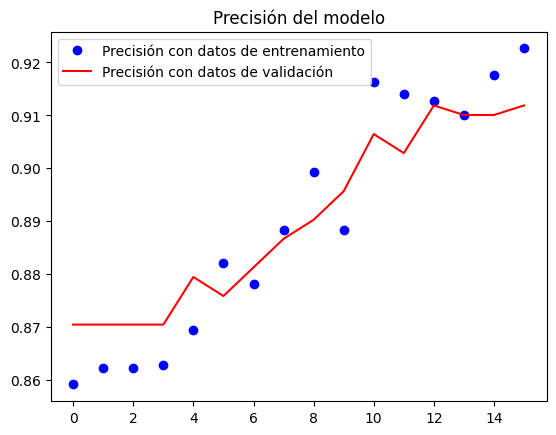

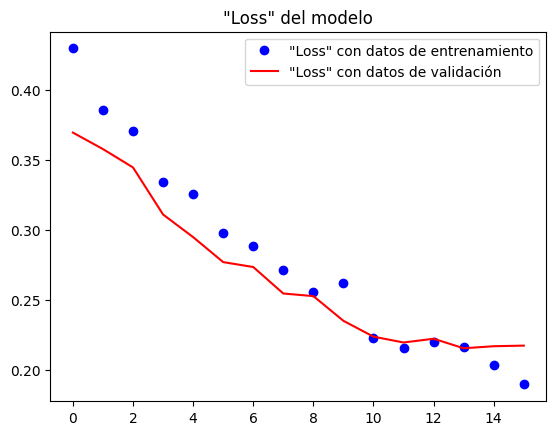

In [32]:
accuracy = x_dropout.history['accuracy']
val_accuracy = x_dropout.history['val_accuracy']
loss = x_dropout.history['loss']
val_loss = x_dropout.history['val_loss']
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, 'bo', label='Precisión con datos de entrenamiento')
plt.plot(epochs, val_accuracy, 'r', label='Precisión con datos de validación')
plt.title('Precisión del modelo')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='"Loss" con datos de entrenamiento')
plt.plot(epochs, val_loss, 'r', label='"Loss" con datos de validación')
plt.title('"Loss" del modelo')
plt.legend()
plt.show()

In [ ]:
## Reevaluación del rendimiento

In [33]:
#
test_predicted_labels = np.round (model.predict(octamer_test))

#
test_predicted_labels = np.argmax(test_predicted_labels, axis=1)
test_predicted_labels.shape, labels_test.shape

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


((1370,), (1370,))

## Matriz de confusión

In [34]:
#Confusion matrix:
print ('Matriz de confusión:')
conf_matrix = confusion_matrix(labels_test, test_predicted_labels)
print (conf_matrix)
print (' ')


print ('Sensibilidad:', conf_matrix[1,1]/(conf_matrix[1,1]+conf_matrix[1,0]))
print ('Especificidad:', conf_matrix[0,0]/(conf_matrix[0,0]+conf_matrix[0,1]))
print ('Valor predictivo positivo (precisión):', conf_matrix[1,1]/(conf_matrix[1,1]+conf_matrix[0,1]))
print ('Valor predictivo negativo:', conf_matrix[0,0]/(conf_matrix[0,0]+conf_matrix[1,0]))
print ('Accuracy:', (conf_matrix[0,0]+conf_matrix[1,1])/(conf_matrix[0,0]+conf_matrix[1,1]+
                                                         conf_matrix[1,0]+conf_matrix[0,1]))

Matriz de confusión:
[[1137   37]
 [  82  114]]
 
Sensibilidad: 0.5816326530612245
Especificidad: 0.9684838160136287
Valor predictivo positivo (precisión): 0.7549668874172185
Valor predictivo negativo: 0.9327317473338802
Accuracy: 0.9131386861313868


## Precisión

In [35]:
precision_score(labels_test, test_predicted_labels)

0.7549668874172185

## Kappa o Indice de Kappa Cohen

In [36]:
cohen_kappa_score(labels_test, test_predicted_labels)

np.float64(0.6082874016693978)

## ROC curve / AUC

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
AUC:  0.93


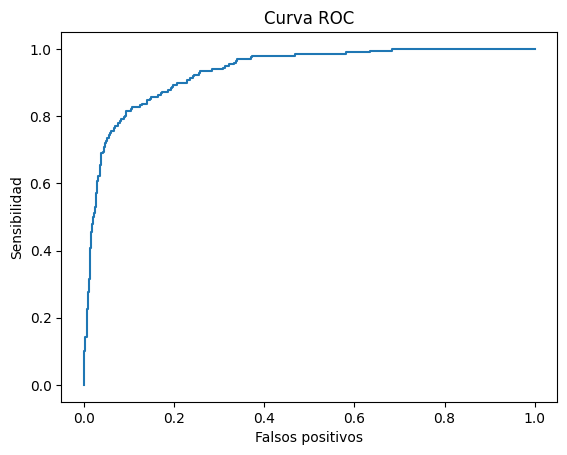

In [37]:
prob=model.predict(octamer_test)
prob_yes=prob[:,1:]
AUC=roc_auc_score(labels_test,prob_yes)
print('AUC: ',round(AUC,2))
fper,tper,tresholds=roc_curve(labels_test,prob_yes)
fig,base=plt.subplots()
base.set_title('Curva ROC')
base.set_xlabel('Falsos positivos')
base.set_ylabel('Sensibilidad')
base.plot(fper,tper)

## Classification report

In [38]:
target_names = ["Class {}".format(i) for i in range(num_classes)]
print(classification_report(labels_test, test_predicted_labels, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.93      0.97      0.95      1174
     Class 1       0.75      0.58      0.66       196

    accuracy                           0.91      1370
   macro avg       0.84      0.78      0.80      1370
weighted avg       0.91      0.91      0.91      1370

